In [1]:
import opendatasets as od

od.download("https://www.kaggle.com/datasets/nandwalritik/yoga-pose-videos-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username:Your Kaggle Key:Dataset URL: https://www.kaggle.com/datasets/nandwalritik/yoga-pose-videos-dataset


100%|██████████| 1.07G/1.07G [00:01<00:00, 1.09GB/s]


In [17]:
import numpy as np 
from __init__ import * 
import os 
import cv2 
import matplotlib.pyplot as plt 
extractor = PoseExtractor(missing_value=-1.0)


Found videos:
C:/Users/dexte/Documents/GitHub/pose-to-biped/pose/yoga-pose-videos-dataset/Yoga_Vid_Collected/Abhay_Bhujangasana.mp4
C:/Users/dexte/Documents/GitHub/pose-to-biped/pose/yoga-pose-videos-dataset/Yoga_Vid_Collected/Abhay_Padmasana.mp4
C:/Users/dexte/Documents/GitHub/pose-to-biped/pose/yoga-pose-videos-dataset/Yoga_Vid_Collected/Abhay_Shavasana.mp4
C:/Users/dexte/Documents/GitHub/pose-to-biped/pose/yoga-pose-videos-dataset/Yoga_Vid_Collected/Abhay_Tadasana.mp4
C:/Users/dexte/Documents/GitHub/pose-to-biped/pose/yoga-pose-videos-dataset/Yoga_Vid_Collected/Abhay_Trikonasana.mp4
C:/Users/dexte/Documents/GitHub/pose-to-biped/pose/yoga-pose-videos-dataset/Yoga_Vid_Collected/Abhay_Vrikshasana.mp4
C:/Users/dexte/Documents/GitHub/pose-to-biped/pose/yoga-pose-videos-dataset/Yoga_Vid_Collected/Ameya_Bhujangasana.mp4
C:/Users/dexte/Documents/GitHub/pose-to-biped/pose/yoga-pose-videos-dataset/Yoga_Vid_Collected/Ameya_Padmasana.mp4
C:/Users/dexte/Documents/GitHub/pose-to-biped/pose/yoga-p

TypeError: 'NoneType' object is not subscriptable

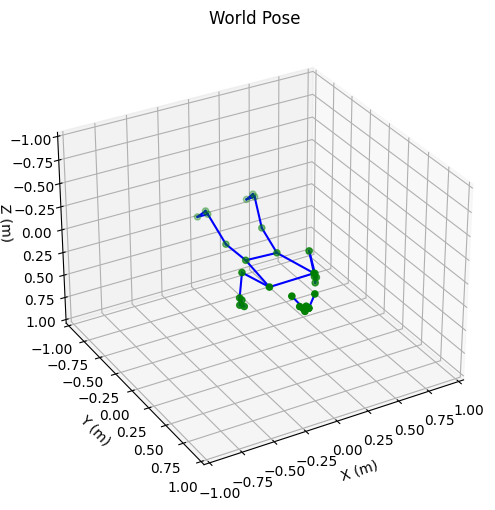

In [ ]:
# Folder containing videos
video_folder = "C:/Users/dexte/Documents/GitHub/pose-to-biped/pose/yoga-pose-videos-dataset/Yoga_Vid_Collected/"

# Supported video extensions
video_exts = (".mp4", ".avi", ".mov", ".mkv", ".wmv")

# List all video files in folder
video_files = [
    os.path.join(video_folder, f)
    for f in os.listdir(video_folder)
    if f.lower().endswith(video_exts)
]

print("Found videos:")
for v in video_files:
    print(v)
fig = plt.figure(figsize=(6, 6), dpi=100)
ax = fig.add_subplot(111, projection="3d")
fig.canvas.draw()

plot_img = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
plot_w, plot_h = fig.canvas.get_width_height()
plot_img = plot_img.reshape((plot_h, plot_w, 3))
plot_img = cv2.cvtColor(plot_img, cv2.COLOR_RGB2BGR)
cap = cv2.VideoCapture(video_files[0])
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
video_width = frame_width + plot_w
video_height = max(frame_height, plot_h)
# Open videos one at a time
for video_path in video_files:
    print(f"\nPlaying: {video_path}")
    
    cap = cv2.VideoCapture(video_path)
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break   # End of video
        frame=frame[100:-100,100:-100]
        landmarks = extractor.process(frame)
        plt.cla()
        ax = extractor.plot_world_landmarks(landmarks, ax)
        ax.set_xlim([-1, 1])
        ax.set_ylim([-1, 1])
        ax.set_zlim([-1, 1])
        ax.view_init(elev=-150, azim=-60)
        fig.canvas.draw()
        plot_img = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
        plot_img = plot_img.reshape((plot_h, plot_w, 3))
        plot_img = cv2.cvtColor(plot_img, cv2.COLOR_RGB2BGR)
        frame = cv2.resize(frame, (frame_width, frame_height))
        plot_img = cv2.resize(plot_img, (plot_w, plot_h))
        combined = np.zeros((video_height, video_width, 3), dtype=np.uint8)
        combined[0:frame_height, 0:frame_width] = frame
        combined[0:plot_h, frame_width:frame_width + plot_w] = plot_img

        cv2.imshow("Video Player", combined)
        # Press q to skip to next video
        if cv2.waitKey(25) & 0xFF == ord('q'):
            break

    cap.release()

cv2.destroyAllWindows()

In [ ]:
def quickconvert(filepath):
     # Folder containing videos
    video_folder = "C:/Users/dexte/Documents/GitHub/pose-to-biped/pose/yoga-pose-videos-dataset/Yoga_Vid_Collected/"
    # Supported video extensions
    video_exts = (".mp4", ".avi", ".mov", ".mkv", ".wmv")
    # List all video files in folder
    video_files = [
        os.path.join(video_folder, f)
        for f in os.listdir(video_folder)
        if f.lower().endswith(video_exts)
    ]
    print("Found videos:")
    for v in video_files:
        print(v)
    # Open videos one at a time
    X=[]
    c=0
    inds=[]
    for video_path in video_files:
        print(f"\nPlaying: {video_path}")
        
        cap = cv2.VideoCapture(video_path)
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break   # End of video
            frame=frame[100:-100,100:-100]
            landmarks = extractor.process(frame)
            X.append(landmarks)
            c+=1
        inds.append(c)
        cap.release()
        np.save(filepath+"/X",np.array(X))
        np.save(filepath+"/IND",np.array(inds))

    cv2.destroyAllWindows()
    
quickconvert("C:/Users/dexte/Documents/GitHub/pose-to-biped/models/data")

Found videos:
C:/Users/dexte/Documents/GitHub/pose-to-biped/pose/yoga-pose-videos-dataset/Yoga_Vid_Collected/Abhay_Bhujangasana.mp4
C:/Users/dexte/Documents/GitHub/pose-to-biped/pose/yoga-pose-videos-dataset/Yoga_Vid_Collected/Abhay_Padmasana.mp4
C:/Users/dexte/Documents/GitHub/pose-to-biped/pose/yoga-pose-videos-dataset/Yoga_Vid_Collected/Abhay_Shavasana.mp4
C:/Users/dexte/Documents/GitHub/pose-to-biped/pose/yoga-pose-videos-dataset/Yoga_Vid_Collected/Abhay_Tadasana.mp4
C:/Users/dexte/Documents/GitHub/pose-to-biped/pose/yoga-pose-videos-dataset/Yoga_Vid_Collected/Abhay_Trikonasana.mp4
C:/Users/dexte/Documents/GitHub/pose-to-biped/pose/yoga-pose-videos-dataset/Yoga_Vid_Collected/Abhay_Vrikshasana.mp4
C:/Users/dexte/Documents/GitHub/pose-to-biped/pose/yoga-pose-videos-dataset/Yoga_Vid_Collected/Ameya_Bhujangasana.mp4
C:/Users/dexte/Documents/GitHub/pose-to-biped/pose/yoga-pose-videos-dataset/Yoga_Vid_Collected/Ameya_Padmasana.mp4
C:/Users/dexte/Documents/GitHub/pose-to-biped/pose/yoga-p